# 01 · Exploratory Data Analysis and Preprocessing

Loads the UCI *Estimation of Obesity Levels* dataset (2,111 respondents, 17 attributes), inspects the
feature distributions, and sets up the shared preprocessing used by the transformer models:

- drop `Weight` (it directly defines the BMI-based target) and `Gender` (class-imbalanced across genders)
- label-encode the categorical features and the 7-class target `NObeyesdad`
- Z-score the continuous features

> **Note:** this is an archival notebook from the original MTFC 2025 run. Outputs are preserved as-is; the dataset (`ObesityDataSet_raw_and_data_sinthetic.csv`) and trained model files are not included in the repo (see the main README for download links).

## Load, clean, and encode

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tab_transformer_pytorch import TabTransformer

# ------------------------
# Data Loading and Preprocessing
# ------------------------

# Load data and drop unwanted columns
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
print(df.describe())
df = df.drop(['Gender', 'Weight'], axis=1)

# Define target column
target_col = "NObeyesdad"

# Identify categorical and numerical columns:
# Assume categorical columns are of object type
categorical_cols = [col for col in df.select_dtypes(include=['object']).columns.tolist() if col != target_col]
numerical_cols = df.select_dtypes(exclude=['object']).columns.tolist()
# Remove the target column from numerical columns (if present)
if target_col in numerical_cols:
    numerical_cols.remove(target_col)

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

# Convert target to numeric labels
le_target = LabelEncoder()
df[target_col] = le_target.fit_transform(df[target_col])

# Process categorical columns: use label encoding so that each category is represented as an integer index.
for col in categorical_cols:
    le_cat = LabelEncoder()
    df[col] = le_cat.fit_transform(df[col])

# Scale numerical columns using z-score scaling
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Create separate DataFrames for categorical and continuous features

X_cat = df[categorical_cols]
X_cont = df[numerical_cols]
y = df[target_col]

# For the TabTransformer, we need the number of unique values per categorical feature.
categories = [int(X_cat[col].nunique()) for col in categorical_cols]
num_continuous = len(numerical_cols)
print("Categories (cardinalities):", categories)
print("Number of continuous features:", num_continuous)

               Age       Height       Weight         FCVC          NCP  \
count  2111.000000  2111.000000  2111.000000  2111.000000  2111.000000   
mean     24.315964     1.701620    86.586035     2.418986     2.685651   
std       6.357078     0.093368    26.191163     0.533996     0.778079   
min      14.000000     1.450000    39.000000     1.000000     1.000000   
25%      20.000000     1.630000    65.470000     2.000000     2.660000   
50%      23.000000     1.700000    83.000000     2.390000     3.000000   
75%      26.000000     1.770000   107.430000     3.000000     3.000000   
max      61.000000     1.980000   173.000000     3.000000     4.000000   

              CH2O          FAF          TUE  
count  2111.000000  2111.000000  2111.000000  
mean      2.008053     1.010313     0.657861  
std       0.612950     0.850613     0.608926  
min       1.000000     0.000000     0.000000  
25%       1.585000     0.125000     0.000000  
50%       2.000000     1.000000     0.625000  
75% 

## Selected feature distributions

Saves the 2×2 summary figure used in the paper (`results/UCI_selected_4_plots.png`).

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

def save_selected_4_plots(df, columns, titles, output_file="selected_4_plots.png"):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flatten()

    for i, (column, title) in enumerate(zip(columns, titles)):
        ax = axes[i]
        col_data = df[column].dropna()

        if pd.api.types.is_numeric_dtype(col_data):
            ax.hist(col_data, bins=30, color='#fcc479', edgecolor='black')
            ax.set_title(f'{title}')
            ax.set_xlabel(title)
            ax.set_ylabel("Count")
        elif pd.api.types.is_categorical_dtype(col_data) or pd.api.types.is_object_dtype(col_data):
            value_counts = col_data.value_counts().head(20)
            ax.bar(value_counts.index.astype(str), value_counts.values, color='#2d4857', edgecolor='black')
            ax.set_title(f'{title}')
            ax.set_ylabel("Count")
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.text(0.5, 0.5, f"Can't plot {title}", ha='center', va='center')
            ax.set_title(f'{title}')

    plt.tight_layout()
    plt.savefig(output_file, dpi=300)
    plt.close(fig)

# Load data and define columns + custom titles
df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')
selected_columns = ["NObeyesdad", "Gender", "FAF", "Height"]
custom_titles = ["Weight Class", "Gender", "Physical Activity Per Week", "Height(m)"]

# Save plot
save_selected_4_plots(df, selected_columns, custom_titles, output_file='UCI_selected_4_plots.png')

## All feature distributions

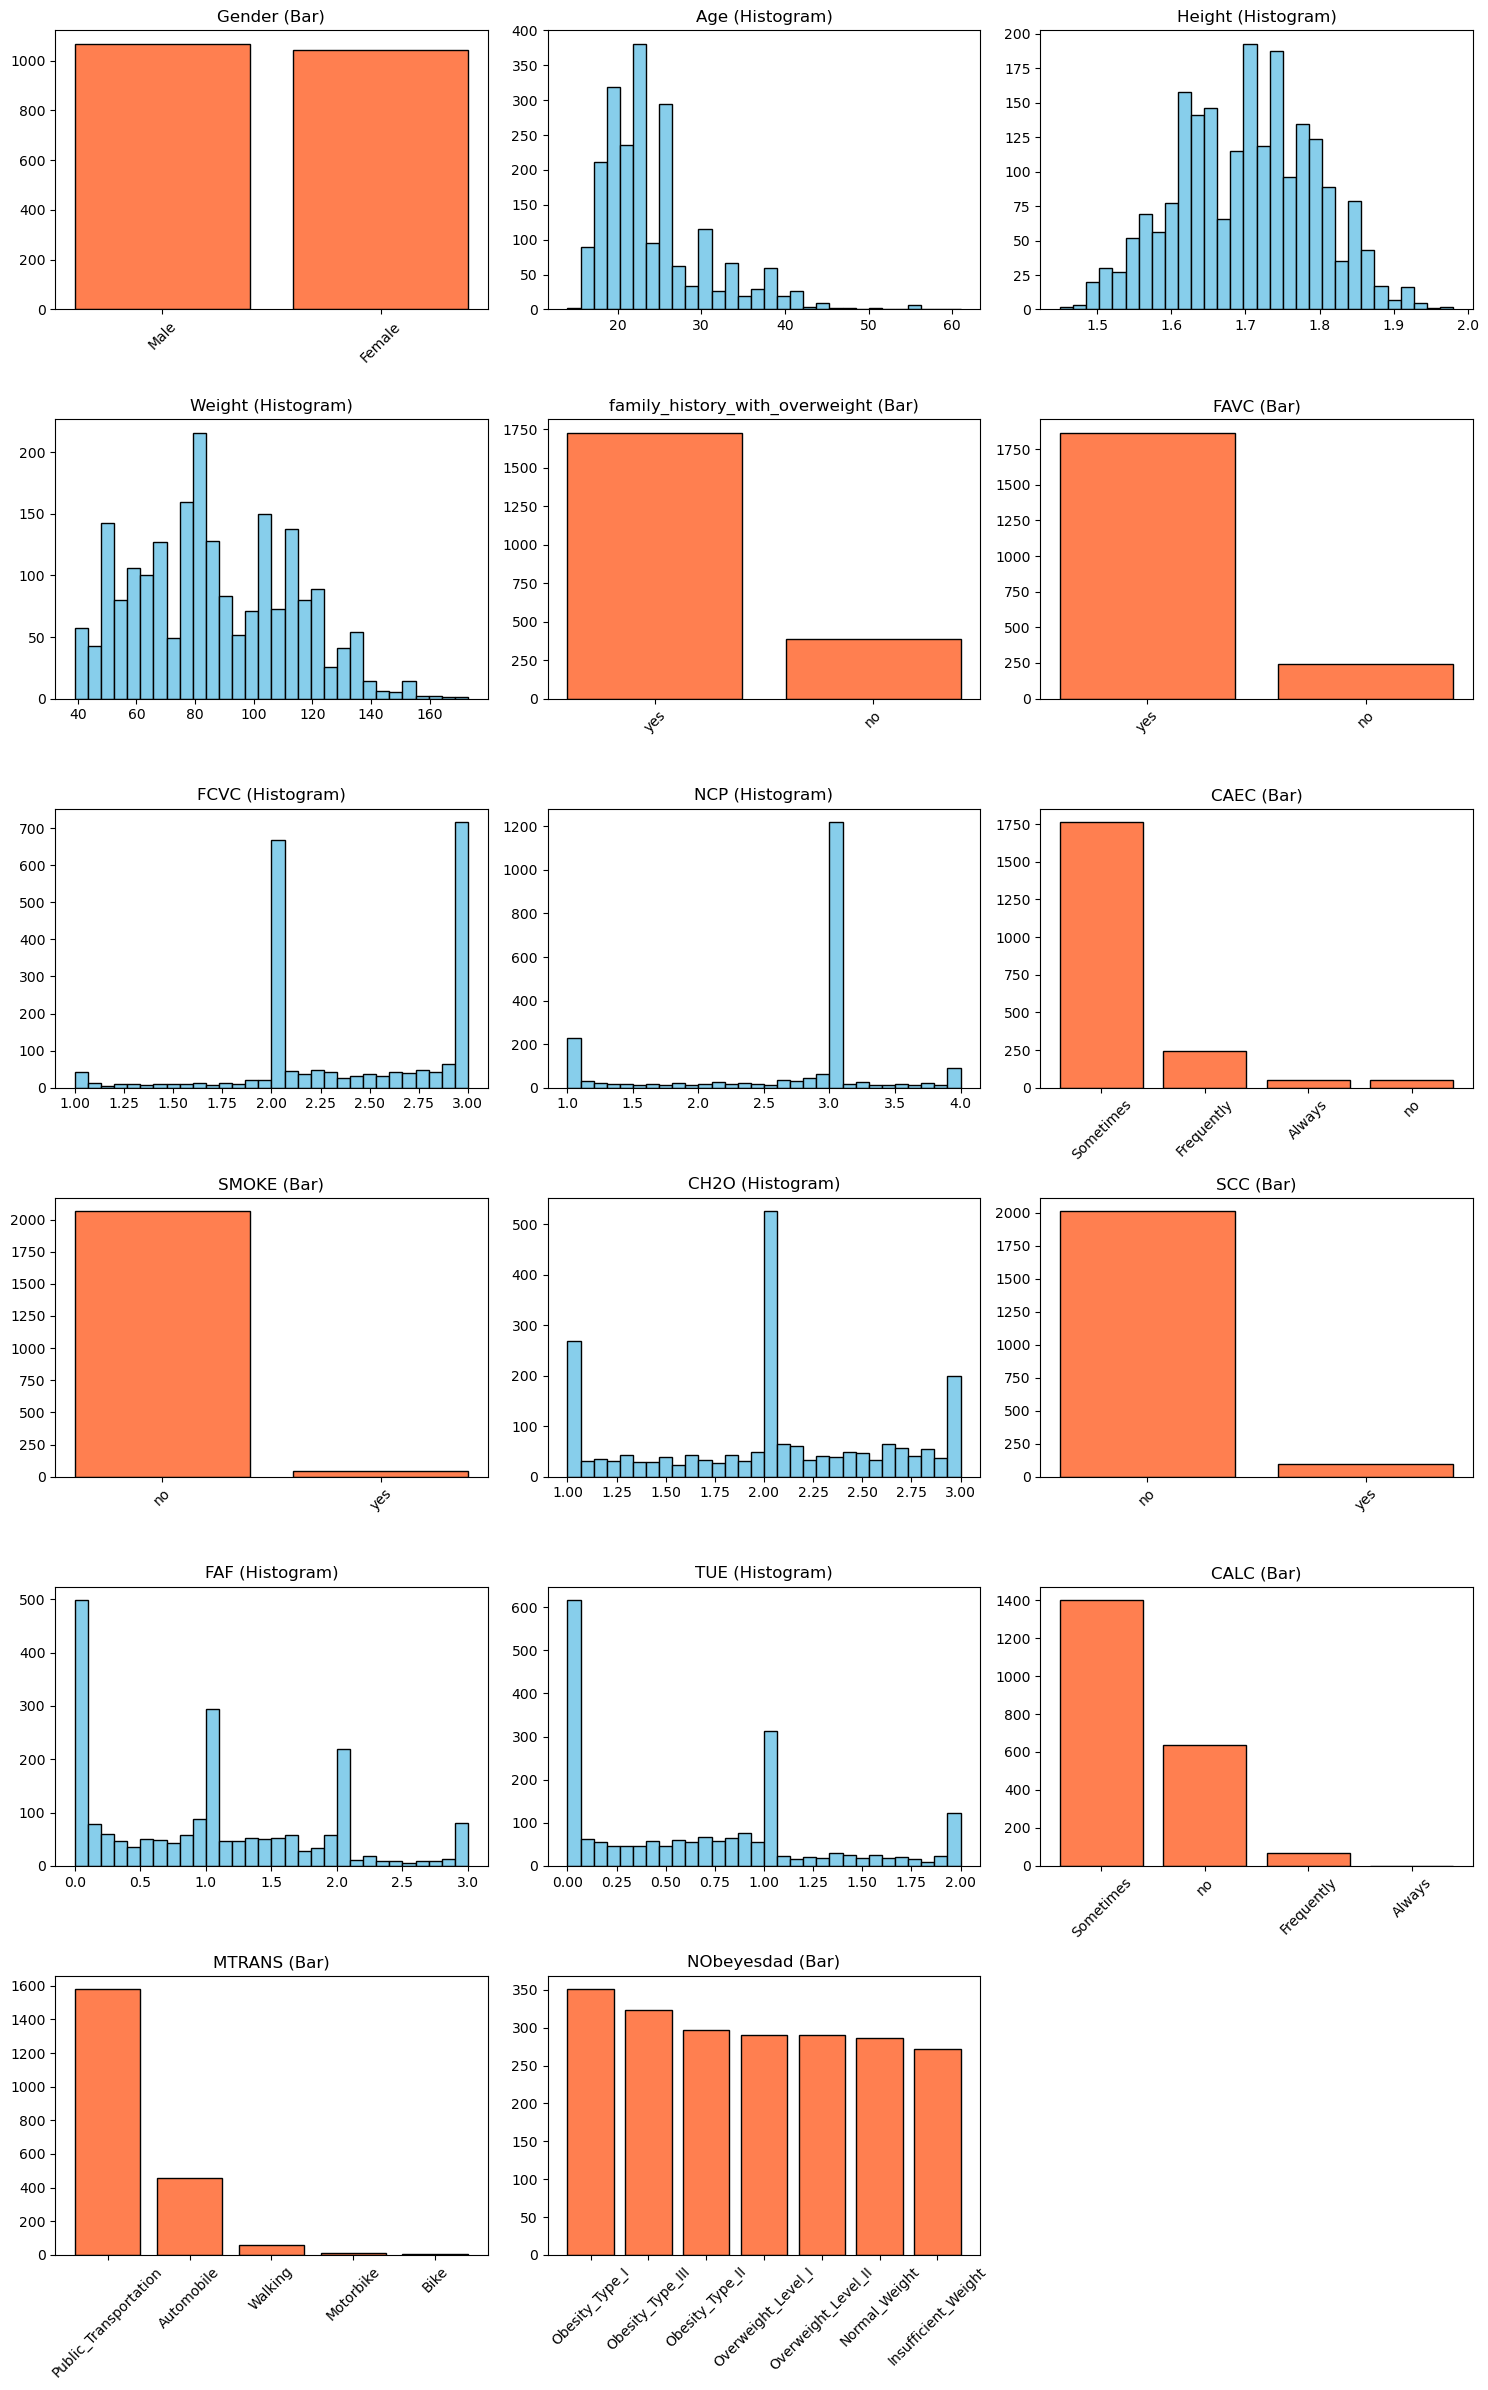

In [3]:
# Try this to test it
import seaborn as sns
#df = sns.load_dataset("ObesityDataSet_raw_and_data_sinthetic.csv")
plot_dataframe_columns_subplots(df)